<a href="https://colab.research.google.com/github/RyanSVargas/Quant-Finance-Research/blob/main/07_Geometric_Brownian_Motion/GBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-192/16381214.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", progress=False)['Close'].squeeze()
/tmp/ipython-input-192/16381214.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", progress=False)['Close'].squeeze()
/tmp/ipython-input-192/16381214.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", progress=False)['Close'].squeeze()
/tmp/ipython-input-192/16381214.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", progress=False)['Close'].squeeze()
/tmp/ipython-input-192/16381214.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", progress=False)['Close'].squeeze()
/tmp/ipython-input-192/16381214.py:16: F

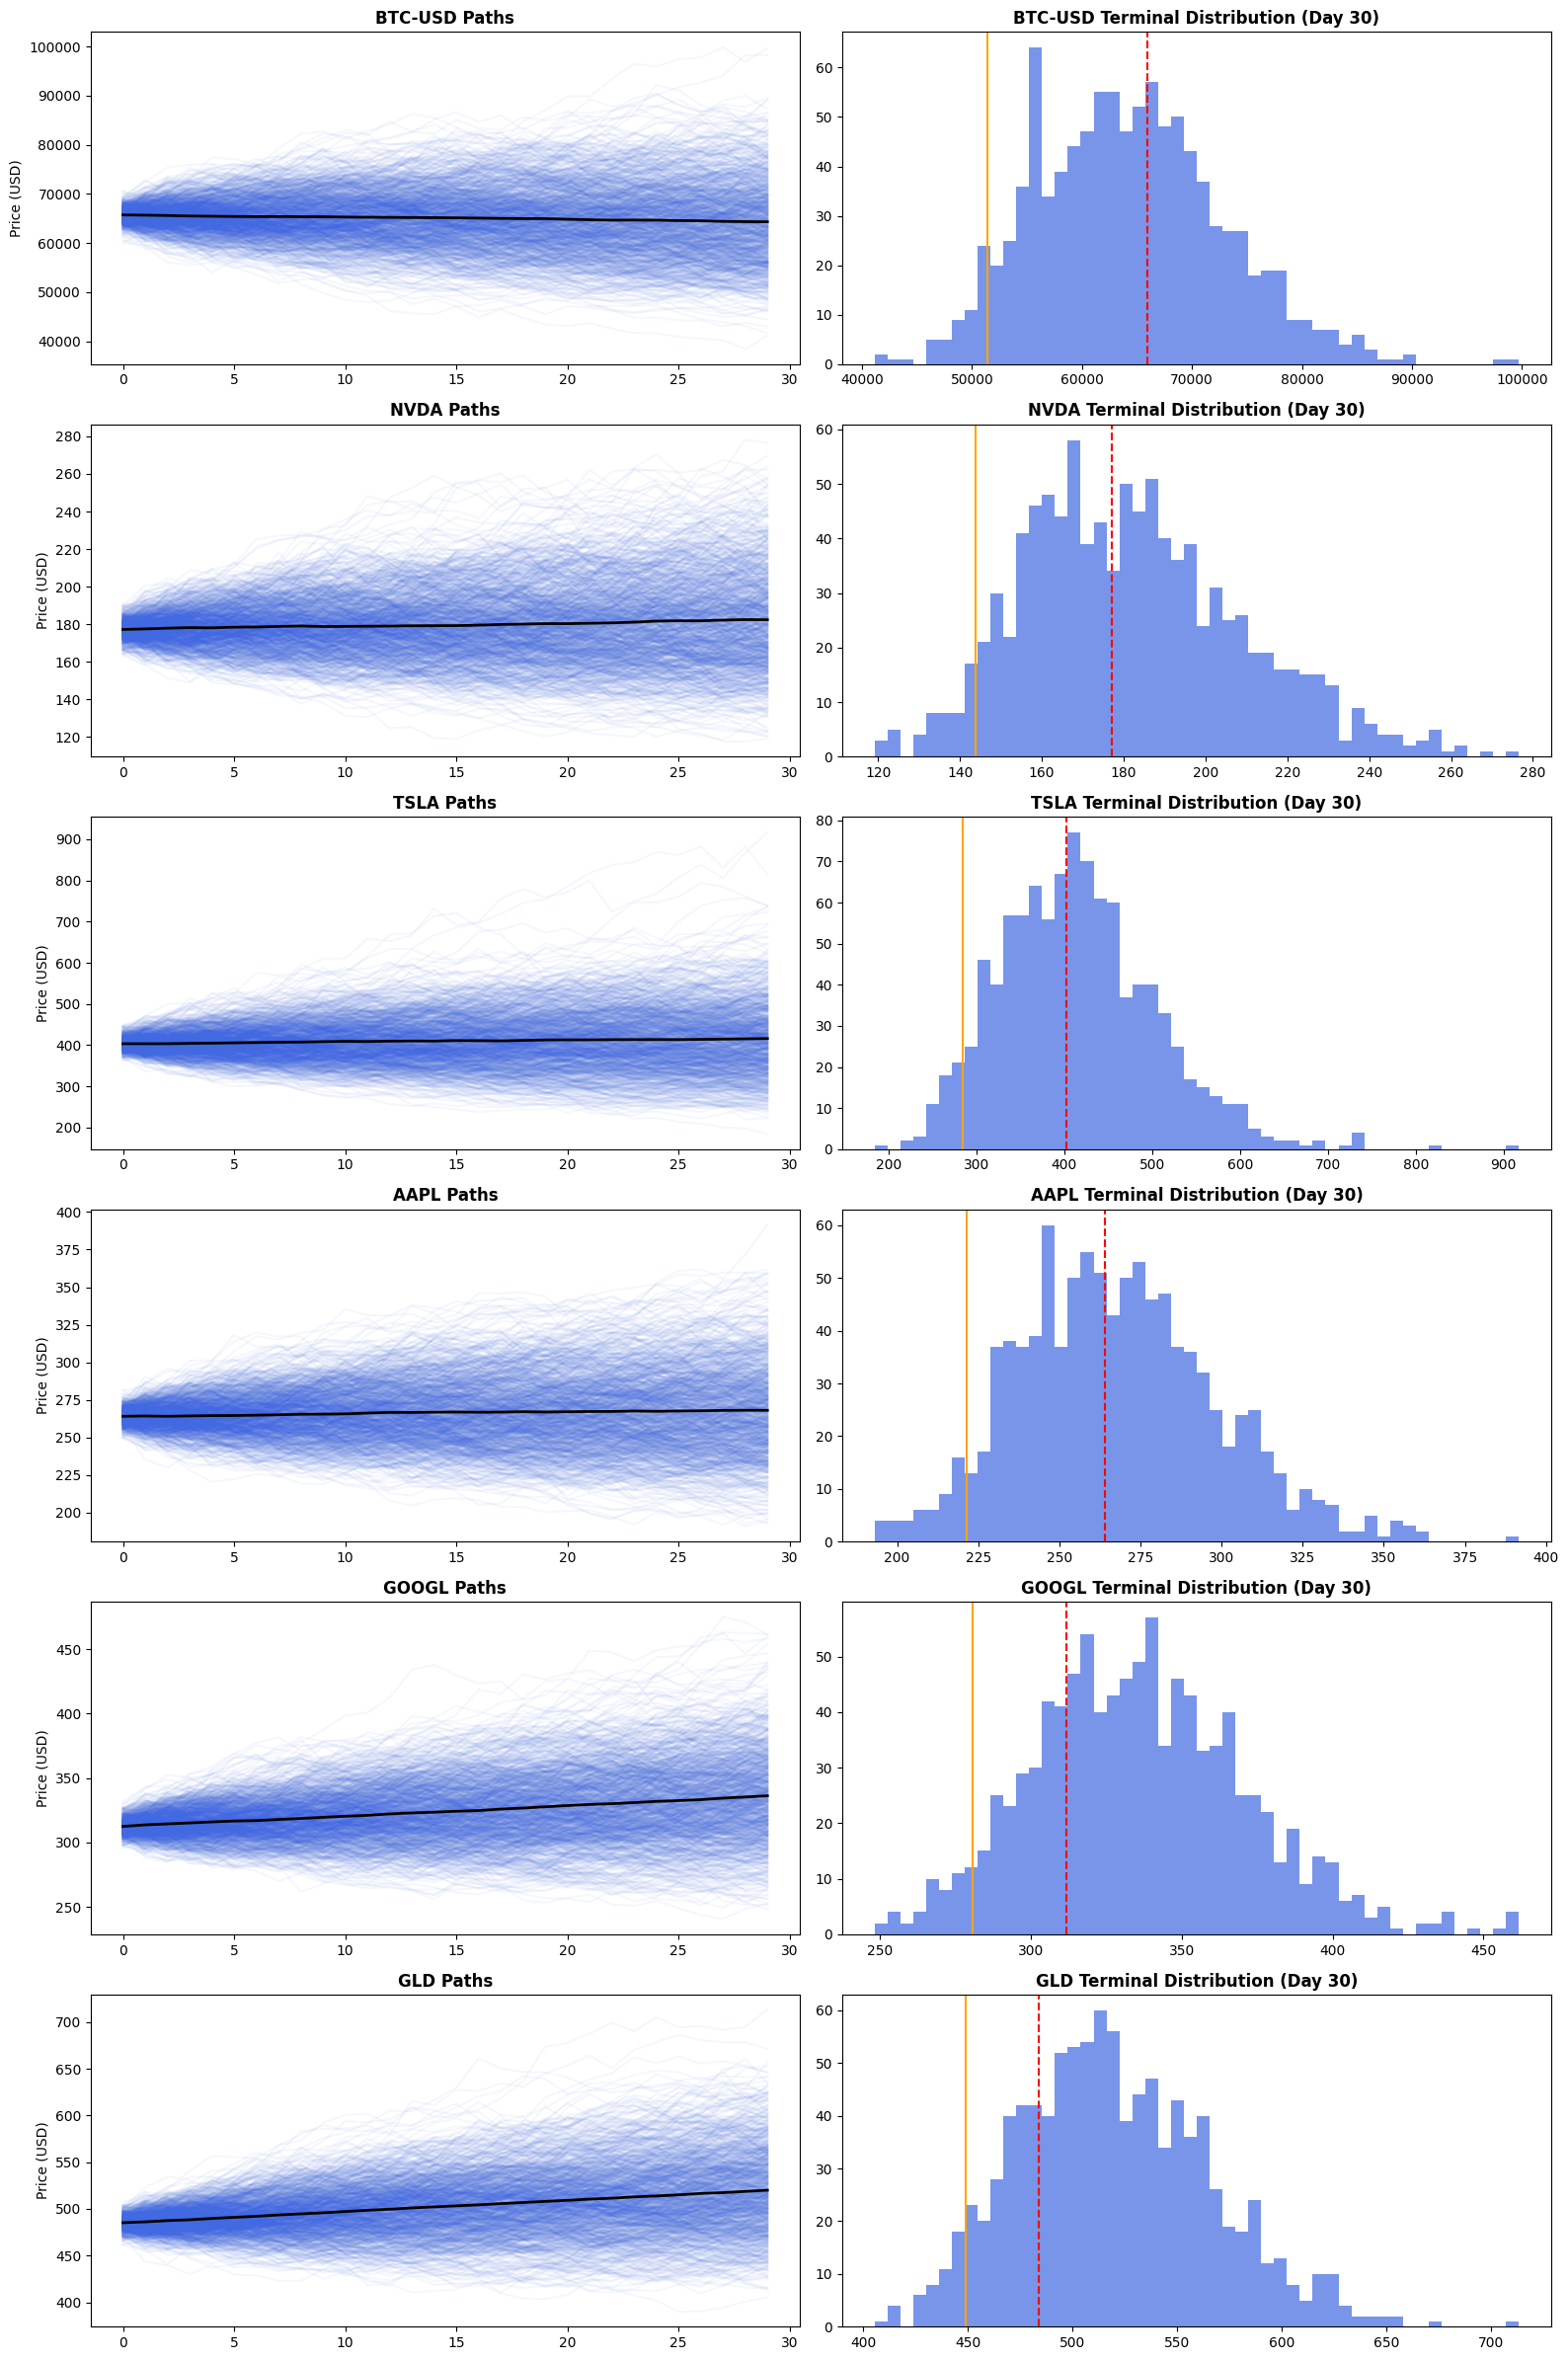

In [5]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup & Data
tickers = ["BTC-USD", "NVDA", "TSLA", "AAPL", "GOOGL", "GLD"]
n_sims = 1000  # Increased for statistical significance
days = 30
dt = 1/252
T = days * dt

fig, axes = plt.subplots(len(tickers), 2, figsize=(16, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    # Data Ingestion
    df = yf.download(ticker, period="1y", progress=False)['Close'].squeeze()
    returns = np.log(df / df.shift(1)).dropna()

    # Parameters
    mu, sigma, S0 = float(returns.mean()*252), float(returns.std()*np.sqrt(252)), float(df.iloc[-1])

    # Vectorized Simulation
    W = np.cumsum(np.random.standard_normal((n_sims, days)) * np.sqrt(dt), axis=1)
    S_t = S0 * np.exp((mu - 0.5 * sigma**2) * (np.arange(1, days+1) * dt) + sigma * W)

    # Plot 1: Trajectories
    axes[i,0].plot(S_t.T, color='royalblue', alpha=0.05)
    axes[i,0].plot(S_t.mean(axis=0), color='black', lw=2, label='Expectation')
    axes[i,0].set_title(f"{ticker} Paths", fontweight='bold')
    axes[i,0].set_ylabel("Price (USD)")

    # Plot 2: Terminal Distribution (Quant Standard)
    terminal_prices = S_t[:, -1]
    axes[i,1].hist(terminal_prices, bins=50, color='royalblue', alpha=0.7)
    axes[i,1].axvline(S0, color='red', ls='--', label='Current Price')

    # Calculate 5% VaR (Value at Risk)
    var_5 = np.percentile(terminal_prices, 5)
    axes[i,1].axvline(var_5, color='orange', ls='-', label='5% VaR')
    axes[i,1].set_title(f"{ticker} Terminal Distribution (Day 30)", fontweight='bold')

plt.tight_layout()
plt.show()